# El buffer del mercado de carbono forestal: probablemente 6,3 veces más pequeño de lo que el clima exige

**6,3 veces.** Es probable que el colchón de seguridad del mayor programa de bonos de carbono forestal de Estados Unidos sea ese factor más pequeño de lo que el clima exige. Según el escenario, el factor puede ir de 2,2 hasta 8,0.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Forest carbon protocols underestimate climate-driven carbon loss risks* · Nature, 2026-05-20
**DOI:** [10.1038/s41586-026-10571-y](https://doi.org/10.1038/s41586-026-10571-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-28-buffer-pool-bosques-carbono/notebook.ipynb)

*Video corto: pendiente.*

## Qué es un *buffer pool* y por qué importa

Cuando una empresa quiere compensar sus emisiones, una opción es comprar bonos de carbono forestales: alguien planta o conserva bosques, mide cuánto CO₂ capturan, y vende ese carbono como crédito. El comprador "emite menos" en papel.

El problema obvio: los bosques arden, se secan, los insectos los matan. Si el bosque que respalda el bono desaparece, el crédito que vendiste deja de ser real. Para cubrir ese riesgo, los programas guardan un *buffer pool*: un porcentaje de cada bono se aparta como seguro colectivo. Si un bosque se quema, el buffer paga la pérdida.

El **California Air Resources Board (CARB)** corre el programa de bonos forestales más grande de Estados Unidos continental. El equipo de *Environmental Defense Fund* y *CarbonPlan* agarró los 116 proyectos reales del programa CARB y los pasó por un modelo de riesgo de fuego, sequía e insectos que sí mete el cambio climático en la cuenta.

Veamos qué encontraron.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Badgley et al. (2026), Nature | Datos: Source Data Figs. 1, 3, 4'
COLOR_FUEGO = '#DC2626'        # rojo — disturbio dominante con clima
COLOR_SEQUIA = '#D97706'       # amber
COLOR_INSECTOS = '#059669'     # emerald
COLOR_HISTORICO = '#BBBBBB'    # gris — línea base
COLOR_DATOS = '#2563EB'        # azul CaM — proyectos / valores actuales
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'

# ── Setup ──
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Descarga auto si corremos en Colab (sin los CSVs locales)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-05-28-buffer-pool-bosques-carbono'
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for fname in ['riesgo_por_ecorregion.csv', 'buffer_por_proyecto.csv',
              'escenarios_buffer.csv', 'factor_subdimensionamiento.csv']:
    local = f'datos/{fname}'
    if not os.path.exists(local):
        urllib.request.urlretrieve(f'{BASE}/datos/{fname}', local)

# ── Carga ──
eco = pd.read_csv('datos/riesgo_por_ecorregion.csv')
proy = pd.read_csv('datos/buffer_por_proyecto.csv')
esc = pd.read_csv('datos/escenarios_buffer.csv')
fac = pd.read_csv('datos/factor_subdimensionamiento.csv')

print(f'95 ecorregiones CONUS: {len(eco)} filas')
print(f'116 proyectos CARB: {len(proy)} filas')
print(f'Escenarios SSP × cobertura: {len(esc)} filas')
print(f'Escenarios de sensibilidad: {len(fac)} filas')

95 ecorregiones CONUS: 95 filas
116 proyectos CARB: 116 filas
Escenarios SSP × cobertura: 6 filas
Escenarios de sensibilidad: 7 filas


## El fuego es el problema

De los tres disturbios naturales que el modelo considera (fuego, sequía, insectos), uno responde al clima con una intensidad fuera de escala. Los otros dos, mucho menos.

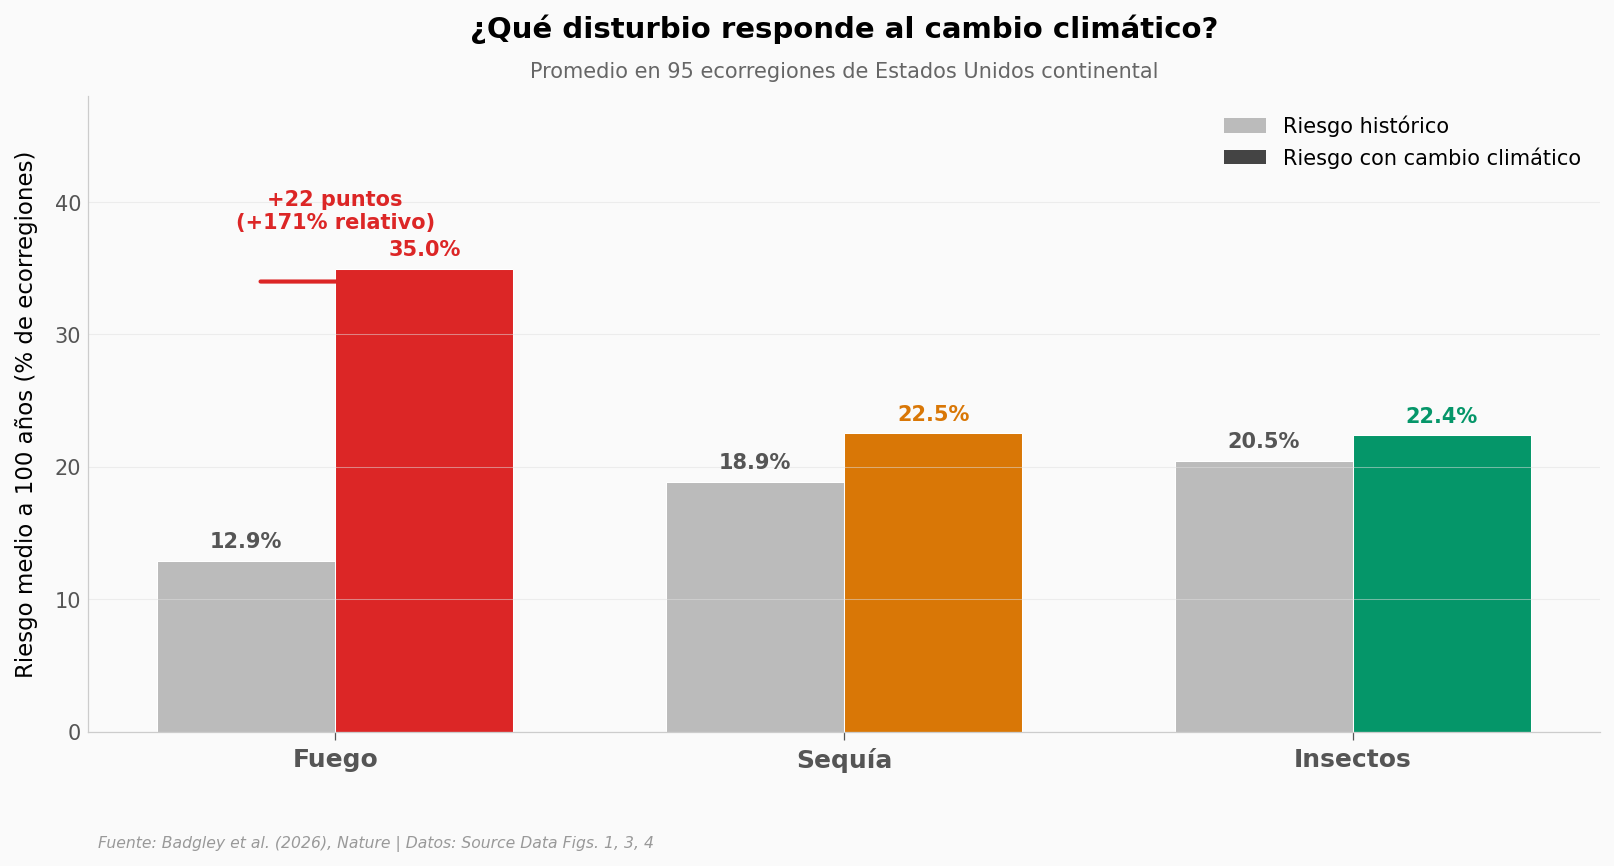

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

disturbios = ['Fuego', 'Sequía', 'Insectos']
colores = [COLOR_FUEGO, COLOR_SEQUIA, COLOR_INSECTOS]
hist_means = [eco['fire_historical_pct'].mean(),
              eco['drought_historical_pct'].mean(),
              eco['insect_historical_pct'].mean()]
cc_means = [eco['fire_climatechange_pct'].mean(),
            eco['drought_climatechange_pct'].mean(),
            eco['insect_climatechange_pct'].mean()]

x = np.arange(len(disturbios))
w = 0.35

bars_h = ax.bar(x - w/2, hist_means, w, color=COLOR_HISTORICO,
                edgecolor='white', linewidth=0.5, label='Histórico')
bars_c = ax.bar(x + w/2, cc_means, w, color=colores,
                edgecolor='white', linewidth=0.5, label='Con cambio climático')

# Etiquetas encima de cada barra
for i, (h, c) in enumerate(zip(hist_means, cc_means)):
    ax.text(i - w/2, h + 1, f'{h:.1f}%', ha='center', fontsize=10,
            color='#555555', fontweight='bold')
    ax.text(i + w/2, c + 1, f'{c:.1f}%', ha='center', fontsize=10,
            color=colores[i], fontweight='bold')

# Flecha del salto del fuego
ax.annotate('', xy=(-w/2 + 0.02, 34), xytext=(w/2 + 0.02, 34),
            arrowprops=dict(arrowstyle='<-', color=COLOR_FUEGO, lw=2))
ax.text(0, 38, '+22 puntos\n(+171% relativo)', ha='center', fontsize=10,
        color=COLOR_FUEGO, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(disturbios, fontsize=12, fontweight='bold')
ax.set_ylabel('Riesgo medio a 100 años (% de ecorregiones)', fontsize=11)
ax.set_title('¿Qué disturbio responde al cambio climático?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Promedio en 95 ecorregiones de Estados Unidos continental',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 48)

# Leyenda manual (las barras con clima usan colores distintos)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLOR_HISTORICO, label='Riesgo histórico'),
                   Patch(facecolor='#444444', label='Riesgo con cambio climático')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_disturbios_hist_vs_cc.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** el fuego pasa del 13% al 35% — más que se duplica. La sequía sube tres puntos. Los insectos, dos. La señal climática se concentra casi entera en el fuego.

Esto es importante porque los protocolos de bonos de carbono CARB definen el buffer pool con tablas de riesgo construidas a partir del clima histórico. Si el calentamiento empuja el riesgo de fuego al doble, una tabla calibrada al pasado va a quedarse corta — y va a quedarse corta exactamente donde más quema.

## ¿Dónde golpea más fuerte?

El promedio nacional esconde diferencias regionales gigantes. El paper apunta a California y el Intermountain West como las zonas más afectadas. Veamos las 10 ecorregiones donde el cambio climático añade más riesgo absoluto.

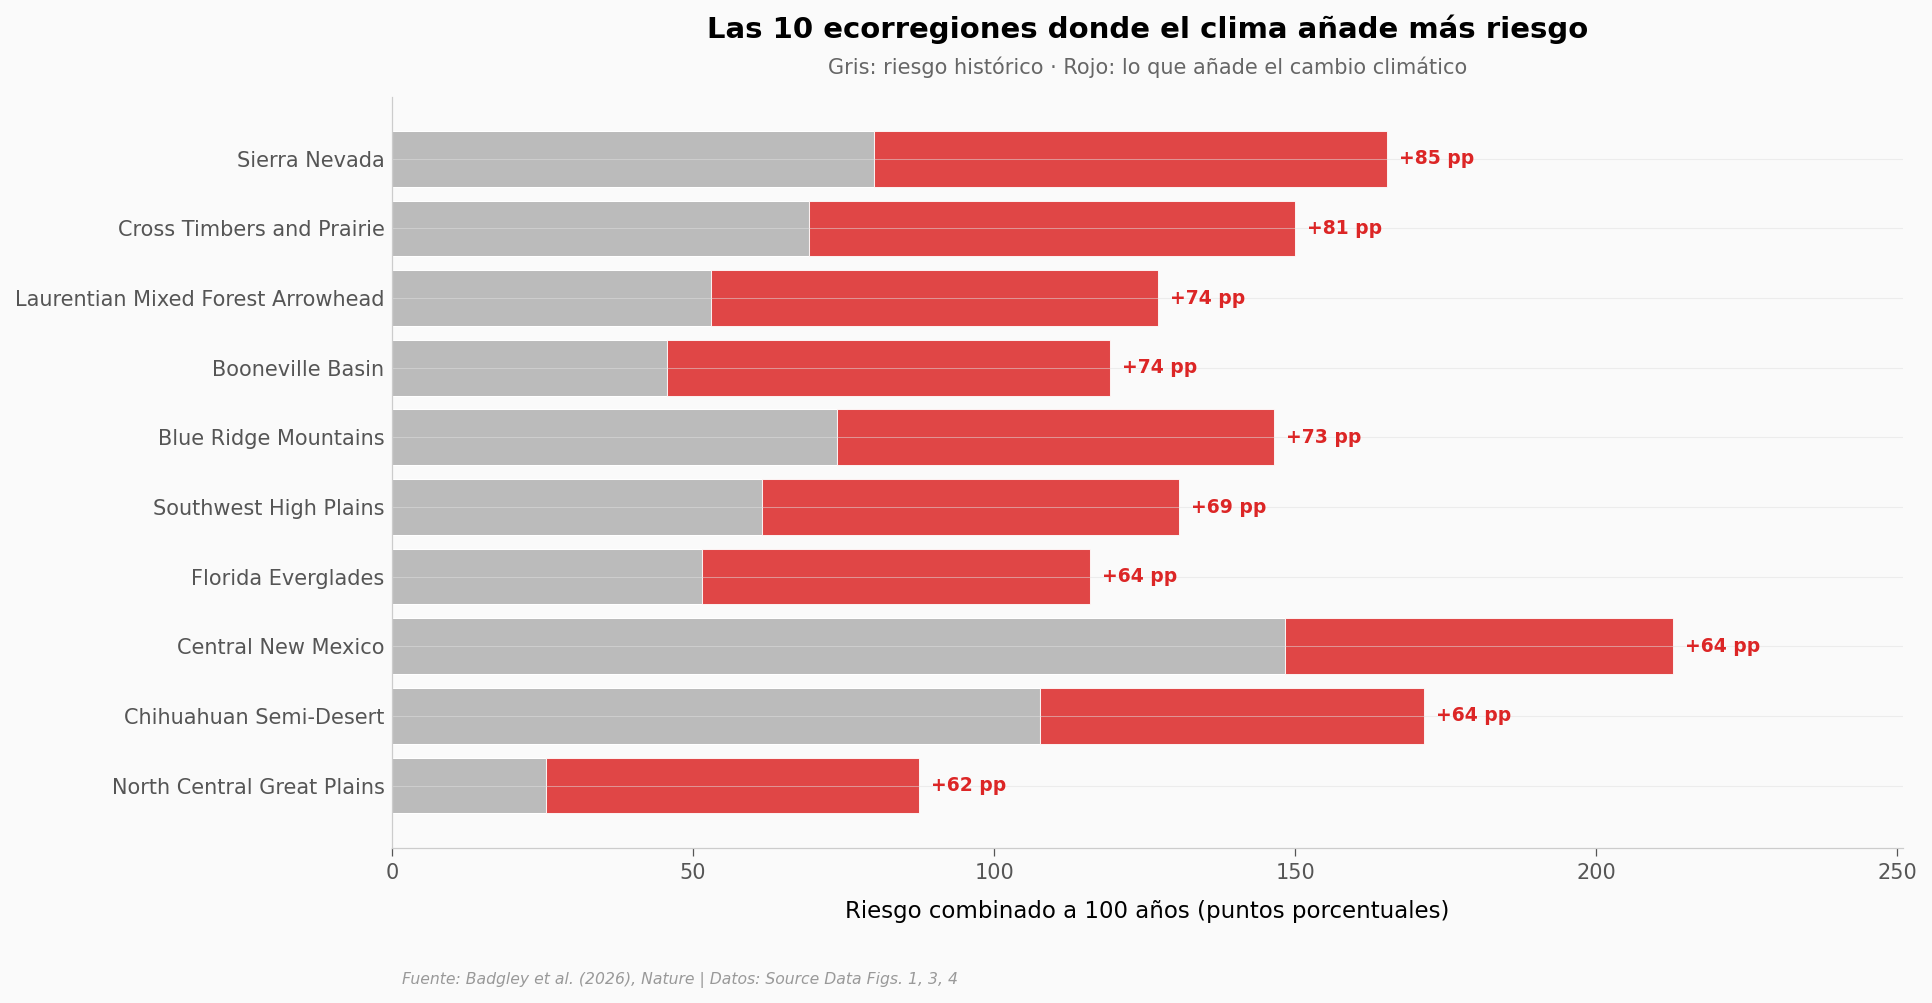


Sierra Nevada acumula 85.3 pp adicionales — el mayor delta de la lista.
Los riesgos combinados pueden superar 100% porque los disturbios pueden ocurrir secuencialmente a lo largo de 100 años.


In [3]:
eco['total_hist_pct'] = (eco['fire_historical_pct'] +
                        eco['drought_historical_pct'] +
                        eco['insect_historical_pct'])
eco['total_cc_pct'] = (eco['fire_climatechange_pct'] +
                      eco['drought_climatechange_pct'] +
                      eco['insect_climatechange_pct'])
eco['delta_pp'] = eco['total_cc_pct'] - eco['total_hist_pct']

top10 = eco.nlargest(10, 'delta_pp').sort_values('delta_pp')

fig, ax = plt.subplots(figsize=(13, 6.5))
y_pos = np.arange(len(top10))

# Barra histórica + extensión con clima
ax.barh(y_pos, top10['total_hist_pct'], color=COLOR_HISTORICO,
        edgecolor='white', linewidth=0.5)
ax.barh(y_pos, top10['delta_pp'], left=top10['total_hist_pct'],
        color=COLOR_FUEGO, alpha=0.85,
        edgecolor='white', linewidth=0.5)

# Etiqueta del salto al final de cada barra
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['total_cc_pct'] + 2, i,
            f"+{row['delta_pp']:.0f} pp",
            va='center', fontsize=9, color=COLOR_FUEGO, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(top10['supersection'], fontsize=10)
ax.set_xlabel('Riesgo combinado a 100 años (puntos porcentuales)', fontsize=11)
ax.set_title('Las 10 ecorregiones donde el clima añade más riesgo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Gris: riesgo histórico · Rojo: lo que añade el cambio climático',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, max(top10['total_cc_pct']) * 1.18)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_top_ecorregiones.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSierra Nevada acumula {top10.iloc[-1]['delta_pp']:.1f} pp adicionales — el mayor delta de la lista.")
print(f"Los riesgos combinados pueden superar 100% porque los disturbios pueden ocurrir secuencialmente a lo largo de 100 años.")

## ¿Y los proyectos reales del CARB cómo quedan?

El programa CARB tiene 116 proyectos forestales activos. CARB le aparta a cada proyecto un porcentaje de su carbono como buffer pool, usando tablas calibradas con el riesgo *histórico*. Si el equipo del paper estima el riesgo de disturbios naturales para cada proyecto con un modelo que sí incluye el clima, la pregunta es: ¿el buffer asignado cubre ese riesgo?

Una manera directa de verlo: poner cada proyecto en un punto, con el buffer que recibió en el eje X y el riesgo natural total estimado en el eje Y. La diagonal `y = x` marca paridad: arriba de la diagonal, el riesgo supera al colchón.

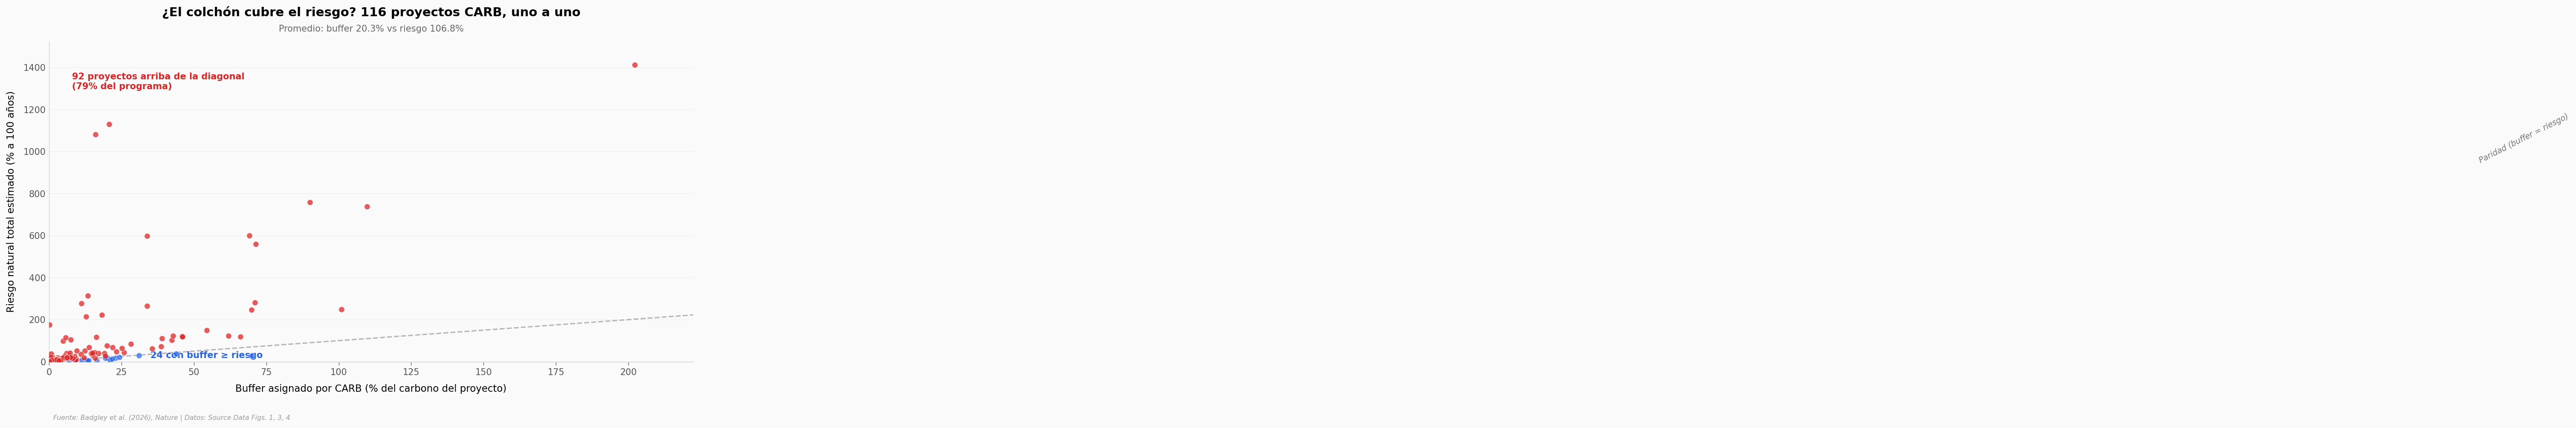


92 de 116 proyectos (79.3%) tienen un riesgo natural total mayor que su buffer asignado.


In [4]:
# Convertir fracciones a porcentajes
proy['buffer_pct'] = proy['carb_buffer_fraction'] * 100
proy['risk_pct'] = proy['total_natural_risk_fraction'] * 100
proy['under_buffered'] = proy['risk_pct'] > proy['buffer_pct']

n_under = proy['under_buffered'].sum()
n_total = len(proy)
pct_under = n_under / n_total * 100

fig, ax = plt.subplots(figsize=(13, 6.5))

# Diagonal y=x (paridad)
lim = max(proy['risk_pct'].max(), proy['buffer_pct'].max()) * 1.08
ax.plot([0, lim], [0, lim], color='#999999', linestyle='--',
        linewidth=1.5, alpha=0.7, zorder=2)
ax.text(lim*0.55, lim*0.62, 'Paridad (buffer = riesgo)',
        fontsize=9, color='#777777', ha='left', style='italic', rotation=27)

# Proyectos subdimensionados (rojo) vs OK (azul)
under = proy[proy['under_buffered']]
ok = proy[~proy['under_buffered']]
ax.scatter(ok['buffer_pct'], ok['risk_pct'], color=COLOR_DATOS, s=42, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=5)
ax.scatter(under['buffer_pct'], under['risk_pct'], color=COLOR_ALERTA, s=42, alpha=0.75,
           edgecolors='white', linewidths=0.5, zorder=6)

# Etiquetas inline
ax.text(35, 18, f'{len(ok)} con buffer ≥ riesgo', fontsize=10,
        color=COLOR_DATOS, fontweight='bold')
ax.text(8, lim*0.85, f'{n_under} proyectos arriba de la diagonal\n({pct_under:.0f}% del programa)',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.set_xlabel('Buffer asignado por CARB (% del carbono del proyecto)', fontsize=11)
ax.set_ylabel('Riesgo natural total estimado (% a 100 años)', fontsize=11)
ax.set_title('¿El colchón cubre el riesgo? 116 proyectos CARB, uno a uno',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Promedio: buffer {proy["buffer_pct"].mean():.1f}% vs riesgo {proy["risk_pct"].mean():.1f}%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, max(proy['buffer_pct'].max()*1.1, 35))
ax.set_ylim(0, lim)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_proyectos_carb.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n{n_under} de {n_total} proyectos ({pct_under:.1f}%) tienen un riesgo natural total mayor que su buffer asignado.")

## El golpe: ¿cuánto buffer tendría que haber?

Vamos al cálculo agregado: ¿cuánto buffer (en MtCO₂e) haría falta hoy si el modelo de riesgo *con clima* tuviera razón? Lo comparamos con el buffer real que CARB tiene apartado. El cociente es el **factor de subdimensionamiento** — cuántas veces más pequeño es el buffer actual de lo que el clima exige.

El paper repite el cálculo en 7 escenarios de sensibilidad (con clima vs sin clima, distintos SSP, distintas severidades). El histograma cuenta la historia.

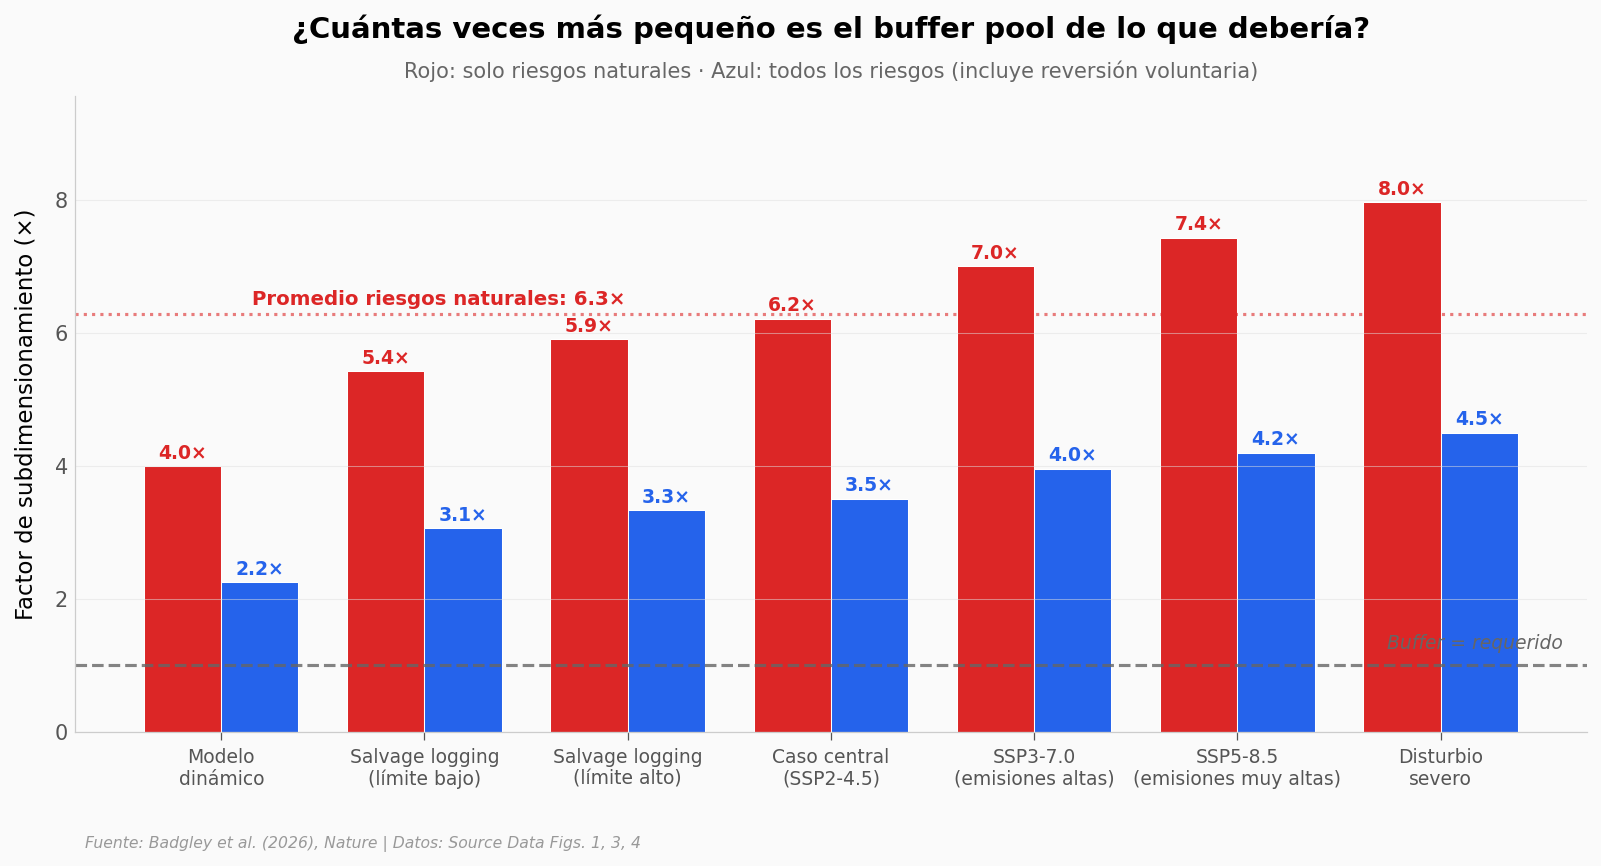


Promedio (riesgos naturales): 6.27×
Rango: 2.25× — 7.96×


In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Etiquetas legibles para cada escenario
labels_es = {
    'Primary': 'Caso central\n(SSP2-4.5)',
    'Salvage logging,lower bound': 'Salvage logging\n(límite bajo)',
    'Salvage logging,upper bound': 'Salvage logging\n(límite alto)',
    'Severe disturbance': 'Disturbio\nsevero',
    'Dynamic': 'Modelo\ndinámico',
    'Primary SSP3-7.0': 'SSP3-7.0\n(emisiones altas)',
    'Primary SSP5-8.5': 'SSP5-8.5\n(emisiones muy altas)',
}

fac_sorted = fac.sort_values('natural_risks_factor').reset_index(drop=True)
x = np.arange(len(fac_sorted))
w = 0.38

bars_nat = ax.bar(x - w/2, fac_sorted['natural_risks_factor'], w,
                  color=COLOR_ALERTA, edgecolor='white', linewidth=0.5)
bars_all = ax.bar(x + w/2, fac_sorted['all_risks_factor'], w,
                  color=COLOR_DATOS, edgecolor='white', linewidth=0.5)

# Línea de paridad (factor = 1: buffer = requerido)
ax.axhline(y=1, color='#666666', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(len(fac_sorted) - 0.4, 1.25, 'Buffer = requerido',
        fontsize=9, color='#666666', ha='right', style='italic')

# Línea del headline 6.3×
mean_natural = fac_sorted['natural_risks_factor'].mean()
ax.axhline(y=mean_natural, color=COLOR_ALERTA, linestyle=':', linewidth=1.5, alpha=0.6)
ax.text(0.15, mean_natural + 0.15, f'Promedio riesgos naturales: {mean_natural:.1f}×',
        fontsize=9.5, color=COLOR_ALERTA, fontweight='bold')

# Etiquetas valor encima de cada barra
for i, row in fac_sorted.iterrows():
    ax.text(i - w/2, row['natural_risks_factor'] + 0.12,
            f"{row['natural_risks_factor']:.1f}×",
            ha='center', fontsize=9, color=COLOR_ALERTA, fontweight='bold')
    ax.text(i + w/2, row['all_risks_factor'] + 0.12,
            f"{row['all_risks_factor']:.1f}×",
            ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([labels_es[s] for s in fac_sorted['scenario']],
                    fontsize=9)
ax.set_ylabel('Factor de subdimensionamiento (×)', fontsize=11)
ax.set_title('¿Cuántas veces más pequeño es el buffer pool de lo que debería?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Rojo: solo riesgos naturales · Azul: todos los riesgos (incluye reversión voluntaria)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, fac_sorted['natural_risks_factor'].max() * 1.2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_factor_subdimensionamiento.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPromedio (riesgos naturales): {mean_natural:.2f}×")
print(f"Rango: {fac_sorted['all_risks_factor'].min():.2f}× — {fac_sorted['natural_risks_factor'].max():.2f}×")

### Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|----------------------|-------------|---------|
| Factor promedio de subdimensionamiento ≈ 6,3× | ✅ | El promedio de los 7 escenarios de la fila *Natural risks* da 6,27× — coincide con el 6,3× reportado en el abstract. |
| El rango de subdimensionamiento va de 2,2× a 8,0× | ✅ | El mínimo (Dynamic, All risks) da 2,25× y el máximo (Severe disturbance, Natural risks) da 7,96×. Coincide con el "2.2- to 8.0-fold" del abstract. |
| El cambio climático aumenta el riesgo a 100 años de pérdida de carbono | ✅ | Los tres disturbios suben con clima, pero la señal está dominada por el fuego: +22 pp (+171% relativo). Sequía e insectos suben mucho menos. |
| California y el Intermountain West son las zonas más afectadas | ⚠️ | Sierra Nevada lidera el ranking de delta absoluto (+85 pp). El top 10 incluye varias supersections del oeste, pero también del este (Blue Ridge, Laurentian Mixed Forest). Mejor leerlo como *las más afectadas incluyen California y el Intermountain West*, no *solo*. |
| 79% de proyectos CARB tienen riesgo natural mayor que su buffer | ✅ | 92 de 116 proyectos quedan arriba de la diagonal `buffer = riesgo`. |

> **Limitaciones:**
> - **Es un modelo, no observación directa.** Los riesgos a 100 años son proyecciones que combinan inventario forestal, satélite y machine learning. El paper presenta intervalos de incertidumbre que aquí no graficamos por celda.
> - **Disturbios secuenciales.** El riesgo combinado por ecorregión puede superar 100% porque fuego, sequía e insectos pueden ocurrir uno detrás del otro en un horizonte de un siglo. No es una probabilidad acumulada en el sentido estricto.
> - **Los autores plantean que los protocolos actuales requieren revisión.** El paper no concluye que el mercado de carbono "esté roto"; argumenta que el buffer está mal dimensionado bajo escenarios de cambio climático.
> - **El factor 6,3×** es un promedio entre escenarios de sensibilidad — la decisión de política depende de cuál escenario climático se considere relevante.

## Ahora tú

1. ¿Qué escenario SSP cambia más el resultado? Compara `escenarios_buffer.csv` y mira cuánto más buffer hace falta entre SSP2-4.5 y SSP5-8.5. ¿La diferencia es lineal o el riesgo se acelera?
2. ¿Hay proyectos donde el fuego solo ya supera el buffer asignado? Filtra `buffer_por_proyecto.csv` con `fire_risk_fraction > carb_buffer_fraction` y cuenta cuántos quedan.
3. ¿Qué pasa si el clima histórico hubiera tenido el riesgo del fuego del escenario climático? Suma `fire_climatechange_pct + drought_historical_pct + insect_historical_pct` por ecorregión y compara con el riesgo combinado actual.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿Cuántos proyectos tienen un riesgo SOLO por fuego mayor que su buffer?

solo_fuego_supera = proy[proy['fire_risk_fraction'] > proy['carb_buffer_fraction']]
n_solo_fuego = len(solo_fuego_supera)

print(f'Proyectos donde solo el riesgo de fuego ya supera el buffer asignado:')
print(f'  {n_solo_fuego} de {len(proy)} ({n_solo_fuego/len(proy)*100:.1f}%)')
print(f'\nProyectos donde el riesgo natural TOTAL supera el buffer:')
print(f'  {proy["under_buffered"].sum()} de {len(proy)} ({proy["under_buffered"].mean()*100:.1f}%)')
print(f'\nLa diferencia entre los dos cuenta cuánto del subdimensionamiento es atribuible solo al fuego.')

Proyectos donde solo el riesgo de fuego ya supera el buffer asignado:
  71 de 116 (61.2%)

Proyectos donde el riesgo natural TOTAL supera el buffer:
  92 de 116 (79.3%)

La diferencia entre los dos cuenta cuánto del subdimensionamiento es atribuible solo al fuego.


## Créditos y reproducibilidad

**Paper:** Badgley et al., *Forest carbon protocols underestimate climate-driven carbon loss risks*, Nature, 2026-05-20.
DOI: [10.1038/s41586-026-10571-y](https://doi.org/10.1038/s41586-026-10571-y)

**Datos:**
- Source Data de Nature (MOESM2, MOESM4, MOESM5) — Figs. 1, 3 y 4 del paper.
- Código y datos reproducibles: [figshare/27988139](https://doi.org/10.6084/m9.figshare.27988139.v1)

**Lab CaM:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — licencia MIT (código) / CC-BY 4.0 (texto, gráficas).

## Fuentes

**Paper**: [Forest carbon protocols underestimate climate-driven carbon loss risks](https://doi.org/10.1038/s41586-026-10571-y)
*Nature, 2026-05-20*

**Source Data** (mismo DOI):
- [Source Data Fig. 1 — Forest carbon protocols underestimate climate-driven carbon loss risks (MOESM2)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10571-y/MediaObjects/41586_2026_10571_MOESM2_ESM.xlsx)
- [Source Data Fig. 3 — Forest carbon protocols underestimate climate-driven carbon loss risks (MOESM4)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10571-y/MediaObjects/41586_2026_10571_MOESM4_ESM.xlsx)
- [Source Data Fig. 4 — Forest carbon protocols underestimate climate-driven carbon loss risks (MOESM5)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10571-y/MediaObjects/41586_2026_10571_MOESM5_ESM.xlsx)

**Código y datos reproducibles**: [Code and data for forest reversal risks and buffer pool manuscript](https://doi.org/10.6084/m9.figshare.27988139.v1) — *figshare*

*16 afirmaciones del notebook verificadas contra estas fuentes*